In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split 


In [2]:
#Generate reproducible nonlinear data

np.random.seed(42)
#Task: (0, 500, 1000)
X = np.linspace(0, 10, 40).reshape(-1,1)


#np.random.normal(0, 5, 40)is to generate random noise
# and add realistic variation to the output data.
#np.random.normal(mean, standard_deviation, number_of_values)
y = 2 + 0.5 * X[:,0] ** 2 + np.random.normal(0,5,40)       #random - used to create noise       *****Task change random

In [3]:
#divide the data
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.30,random_state=42
)
# #Task = change test size to  --- 0.20 0.25 0.30 , put degree 1,2,3,4,5,10
degrees=[1,2,10]

#include bias= false-is to tell plynomialfeatures not to create
#an additional constant column containing only 1s

for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),      #****Task = bias is TRUE
        LinearRegression()
    )

    model.fit(X_train,y_train)
    train_prediction=model.predict(X_train)
    test_prediction=model.predict(X_test)

    train_mse = mean_squared_error(y_train,train_prediction)
    test_mse = mean_squared_error(y_test,test_prediction)

    print(f"PolynomialFeatures:{degree}")
    print(f"Training Mse: {train_mse:.2f}")
    print(f"Testing MSE:{test_mse:.2f}")
    print()

PolynomialFeatures:1
Training Mse: 42.90
Testing MSE:42.99

PolynomialFeatures:2
Training Mse: 20.44
Testing MSE:19.79

PolynomialFeatures:10
Training Mse: 18.26
Testing MSE:38.42



***Ploting***

ValueError: num must be an integer with 1 <= num <= 3, not 4

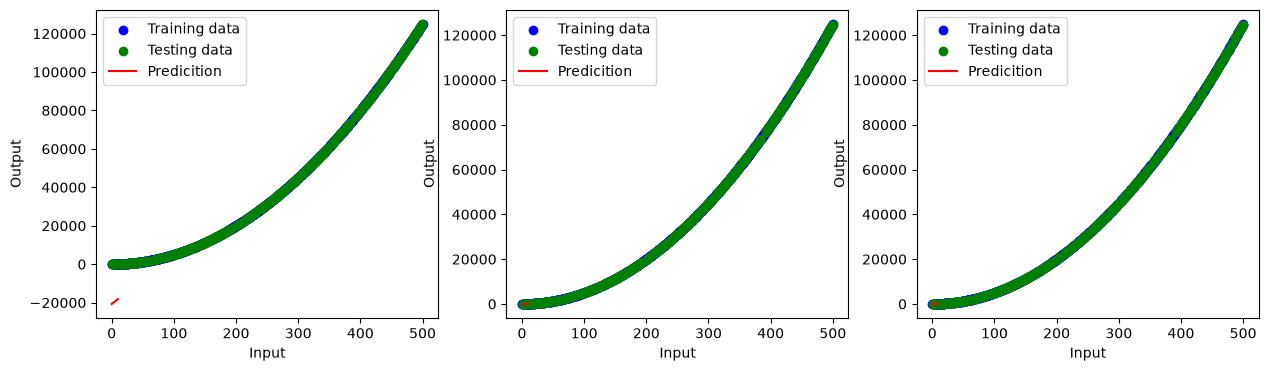

In [9]:
x_plot = np.linspace(0,10,200).reshape(-1,1)

plt.figure(figsize=(15,4))


for index, degree in enumerate(degrees):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(X_train, y_train)
    y_plot = model.predict(x_plot)

    plt.subplot(1, 3, index + 1)
    plt.scatter(X_train, y_train, color="blue", label="Training data")
    plt.scatter(X_test, y_test, color="green", label="Testing data")
    plt.plot(x_plot, y_plot, color="Red", label="Predicition")

    plt.xlabel("Input")
    plt.ylabel("Output")

    plt.legend()
plt.tight_layout()
plt.show()


<h2> Cross validation and model selection

In [19]:
from sklearn.model_selection import cross_val_score
for degree in range(1,11):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model,
        X,
        y,
        cv = 5,
        scoring="neg_mean_squared_error"
    )

    #sckitit-learn returns the neg. value of MSE so, that higher values represent better model performance
    mean_mse = -scores.mean()
    print(f"Degree {degree}: CV MSE = {mean_mse:.2f}")

Degree 1: CV MSE = 326051060.50
Degree 2: CV MSE = 24.62
Degree 3: CV MSE = 24.09
Degree 4: CV MSE = 60016081.84
Degree 5: CV MSE = 534559129.76
Degree 6: CV MSE = 2335450841.25
Degree 7: CV MSE = 7461201433.78
Degree 8: CV MSE = 19972383735.95
Degree 9: CV MSE = 47779591010.46
Degree 10: CV MSE = 105809766010.82


In [23]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X = pd.DataFrame({
    "constant_feature" : [1, 1, 1, 1, 1],
    "almost_constant" : [0, 0, 0, 0, 1],
    "useful_feature" : [10, 20, 30, 40, 50]
})

selector = VarianceThreshold(threshold=0.0)
X_selected = selector.fit_transform(X)

selected_column = X.columns[selector.get_support()]

print("Selected Feature: ", list(selected_column))

Selected Feature:  ['almost_constant', 'useful_feature']


<h3> From given dataset we have to apply, above things, variance threshold and all

<h1>Correlation

             study_hours       att  prv_marks  finl_makrs
study_hours     1.000000  0.879096   0.913926    0.983616
att             0.879096  1.000000   0.996767    0.944433
prv_marks       0.913926  0.996767   1.000000    0.967429
finl_makrs      0.983616  0.944433   0.967429    1.000000


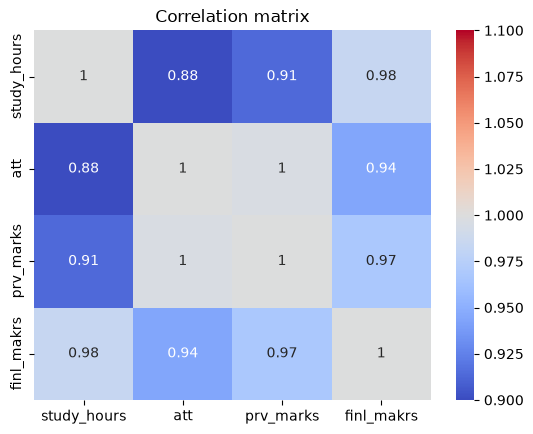

In [34]:
import seaborn as sns


data = pd.DataFrame({
    "study_hours" : [1,2,3,4,5,6,7],
    "att" : [50,55,65,70,80,90,150],
    "prv_marks" : [35,40,50,55,65,75,120],
    "finl_makrs" : [38,45,52,60,70,82,100]
})

corr_matrix = data.corr(numeric_only=True)
print(corr_matrix)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin = 1,
    vmax = 1
)

plt.title("Correlation matrix")
plt.show()

<h1>Chi-Square test

In [35]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
#MinmaxScaler - Avoid negative number

data = load_breast_cancer()
X= data.data
y= data.target

In [36]:
print("No. of Features", X.shape[1])

No. of Features 30


In [38]:
#Chi-square requires non-neg features values

X_non_neg = MinMaxScaler().fit_transform(X)

selector = SelectKBest(score_func=chi2, k=5)
X_selected = selector.fit_transform(X_non_neg, y)

selected_feature = data.feature_names[selector.get_support()]

print("Selected Feature: ")
print(selected_feature)


Selected Feature: 
['mean concavity' 'mean concave points' 'worst perimeter' 'worst area'
 'worst concave points']


<h3>Example 2 of Chi-Square

In [41]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, f_classif
# from sklearn.feature_extraction import load_

In [42]:
iris = load_iris()
X,y = iris.data, iris.target

In [48]:
selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X, y)

import numpy as np
selected_feature = np.array(iris.feature_names)[selector.get_support()]

print("Selected Feature: ")
print(selected_feature)

Selected Feature: 
['petal length (cm)' 'petal width (cm)']
